# Random Forest Training for PTM Prediction

This notebook trains Random Forest models for multi-label classification of protein post-translational modifications.

## Overview
- **Task**: Multi-label binary classification (3 labels)
- **Model**: Random Forest with class weighting
- **Challenge**: Severe class imbalance (1:7 to 1:25 ratios)
- **Solution**: `class_weight='balanced'` to handle imbalance

## Labels to Predict:
1. S-glutathionylation (very rare: ~5% positive)
2. S-nitrosylation (rare: ~12% positive)
3. S-palmitoylation (very rare: ~3% positive)

In [2]:
import os

N_CORES = 16
# 1. Set Environment Variables (Must be done BEFORE importing sklearn/numpy)
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_CORES)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_CORES)
os.environ["NUMEXPR_NUM_THREADS"] = str(N_CORES)

## 1. Import Libraries

In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    roc_auc_score, 
    hamming_loss,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Data

We load the pre-split training and validation data created by `04_train_val_split.py`.

**Important:** Everyone on the team should use the SAME split files for fair comparison!

In [4]:
# Load train/validation splits
# Adjust path if needed
ENCODING_MTHD = "onehot"
TRAIN_CSV_PATH = f"../data_engineered/{ENCODING_MTHD}/train_with_features_{ENCODING_MTHD}_split.csv"
VAL_CSV_PATH = f"../data_engineered/{ENCODING_MTHD}/val_with_features_{ENCODING_MTHD}_split.csv"
OUTPUT_DIR = f"../output/rf/{ENCODING_MTHD}"

train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"\nDataset shape: {train_df.shape}")

# Show first few rows
train_df.head()

Training samples: 71,208
Validation samples: 17,802

Dataset shape: (71208, 116)


,ID,Sequence,S-glutathionylation,S-nitrosylation,S-palmitoylation,aa_A,aa_C,aa_D,aa_E,aa_F,...,cys_ctx_2_M,cys_ctx_2_N,cys_ctx_2_P,cys_ctx_2_Q,cys_ctx_2_R,cys_ctx_2_S,cys_ctx_2_T,cys_ctx_2_V,cys_ctx_2_W,cys_ctx_2_Y
0,Q9Y6R7,ANCPLSCPANSRYELCGPACPTSCNGAAAPS,0,0,0,0.193548,0.161290,0.000000,0.032258,0.000000,...,False,False,False,False,False,False,False,False,False,False
1,O94903,PNPDFQLLLSLREELCKKLNIPADQVELSMG,0,0,0,0.032258,0.032258,0.064516,0.096774,0.032258,...,False,False,False,False,False,False,False,False,False,False
2,P10833,VSDYDPTIEDSYTKICTVDGIPARLDILDTA,0,1,1,0.064516,0.032258,0.193548,0.032258,0.000000,...,False,False,False,False,False,False,False,True,False,False
3,Q8K2Y7,AACSLVNPKDAAHSGCRSSLSLLHKNTPHVT,0,0,0,0.129032,0.064516,0.032258,0.000000,0.000000,...,False,False,False,False,False,False,False,False,False,False
4,Q9DBA8,PNAYCFSMPMVMHLACVNMRMSMPEALAAAT,0,0,0,0.193548,0.064516,0.000000,0.032258,0.032258,...,False,False,False,False,False,True,False,False,False,False


## 3. Prepare Features and Labels

### Key Steps:
1. Separate features from labels
2. Remove metadata columns (ID, Sequence)
3. **Convert boolean columns to integers** (sklearn requirement)
4. **Remove any non-numeric columns** (prevents errors)
5. Ensure all data is float type

In [5]:
# Define label columns (what we're predicting)
label_cols = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']

# Get feature columns (everything except ID, Sequence, and labels)
feature_cols = [col for col in train_df.columns 
                if col not in ['ID', 'Sequence'] + label_cols]

print(f"Total feature columns: {len(feature_cols)}")
print(f"\nSample features: {feature_cols[:10]}")

Total feature columns: 111

Sample features: ['aa_A', 'aa_C', 'aa_D', 'aa_E', 'aa_F', 'aa_G', 'aa_H', 'aa_I', 'aa_K', 'aa_L']


In [6]:
# Extract features
X_train_df = train_df[feature_cols].copy()
X_val_df = val_df[feature_cols].copy()

# Check data types before conversion
print("Data types in features:")
print(X_train_df.dtypes.value_counts())

Data types in features:
bool       80
float64    24
int64       5
object      2
Name: count, dtype: int64


In [7]:
# IMPORTANT: Convert boolean columns to integers
# sklearn doesn't handle boolean dtypes well, so we convert True/False → 1/0
print("\nConverting boolean columns to integers...")
bool_cols = X_train_df.select_dtypes(include=['bool']).columns
print(f"Found {len(bool_cols)} boolean columns")

for col in bool_cols:
    X_train_df[col] = X_train_df[col].astype(int)
    X_val_df[col] = X_val_df[col].astype(int)

print("✓ Boolean columns converted")


Converting boolean columns to integers...
Found 80 boolean columns
✓ Boolean columns converted


In [8]:
# Check for and remove non-numeric columns (strings)
# These can't be used by Random Forest
non_numeric = X_train_df.select_dtypes(include=['object']).columns

if len(non_numeric) > 0:
    print(f"⚠️  Found {len(non_numeric)} non-numeric columns: {list(non_numeric)}")
    print("Removing them...")
    X_train_df = X_train_df.drop(columns=non_numeric)
    X_val_df = X_val_df.drop(columns=non_numeric)
    feature_cols = [col for col in feature_cols if col not in non_numeric]
    print("✓ Removed")
else:
    print("✓ All columns are numeric")

⚠️  Found 2 non-numeric columns: ['cys_ctx_-1_X', 'cys_ctx_1_B']
Removing them...
✓ Removed


In [9]:
# Convert to numpy arrays and ensure float type
X_train = X_train_df.values.astype(float)
X_val = X_val_df.values.astype(float)

# Extract labels as numpy arrays
y_train = train_df[label_cols].values
y_val = val_df[label_cols].values

print("\nFinal data shapes:")
print(f"X_train: {X_train.shape}  (samples, features)")
print(f"y_train: {y_train.shape}  (samples, labels)")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}")
print("\n✓ Data preparation complete")


Final data shapes:
X_train: (71208, 109)  (samples, features)
y_train: (71208, 3)  (samples, labels)
X_val:   (17802, 109)
y_val:   (17802, 3)

✓ Data preparation complete


## 4. Examine Class Imbalance

Understanding the imbalance helps us interpret model performance.

In [10]:
# Calculate class distribution for each label
print("Class Distribution in Training Data:")
print("="*60)

for idx, label in enumerate(label_cols):
    pos_count = y_train[:, idx].sum()
    neg_count = len(y_train) - pos_count
    ratio = neg_count / pos_count
    
    print(f"\n{label}:")
    print(f"  Negative: {neg_count:,} ({neg_count/len(y_train)*100:.2f}%)")
    print(f"  Positive: {pos_count:,} ({pos_count/len(y_train)*100:.2f}%)")
    print(f"  Imbalance ratio: 1:{ratio:.1f}")

Class Distribution in Training Data:

S-glutathionylation:
  Negative: 67,422 (94.68%)
  Positive: 3,786 (5.32%)
  Imbalance ratio: 1:17.8

S-nitrosylation:
  Negative: 62,363 (87.58%)
  Positive: 8,845 (12.42%)
  Imbalance ratio: 1:7.1

S-palmitoylation:
  Negative: 68,546 (96.26%)
  Positive: 2,662 (3.74%)
  Imbalance ratio: 1:25.7


## 5. Train Random Forest Models

We train **3 separate binary classifiers** (one for each label).

### Why 3 separate models?
This is called the **"Binary Relevance"** approach for multi-label classification:
- Label 1: Is this sequence glutathionylated? (Yes/No)
- Label 2: Is this sequence nitrosylated? (Yes/No)  
- Label 3: Is this sequence palmitoylated? (Yes/No)

### Key Hyperparameters:
- `n_estimators=300`: Build 300 trees (more = better, up to a point)
- `max_depth=None`: Let trees grow fully (no limit)
- `class_weight='balanced'`: **Crucial!** Automatically weights classes inversely proportional to frequencies
- `n_jobs=-1`: Use all CPU cores for parallel training

In [11]:
# Dictionary to store trained models
models = {}

# Train one model per label
for idx, label in enumerate(label_cols):
    print(f"\n{'='*60}")
    print(f"Training Random Forest for: {label}")
    print(f"{'='*60}")
    
    # Show class distribution again
    pos_count = y_train[:, idx].sum()
    neg_count = len(y_train) - pos_count
    print(f"Training samples: {neg_count:,} negative, {pos_count:,} positive")
    print(f"Imbalance ratio: 1:{neg_count/pos_count:.1f}")
    
    # Initialize Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,           # Number of trees in the forest
        max_depth=None,             # Trees can grow to any depth
        min_samples_split=5,        # Min samples required to split a node
        min_samples_leaf=2,         # Min samples required in a leaf node
        max_features='sqrt',        # Number of features to consider: sqrt(total)
        class_weight='balanced',    # Handle imbalance automatically!
        random_state=42,            # For reproducibility
        n_jobs=N_CORES,             # Use 16 CPU cores
        verbose=1                   # Print progress (verbose=1 for debugging)
    )
    
    # Train the model
    print("\nTraining...")
    rf.fit(X_train, y_train[:, idx])
    
    print("✓ Training complete!")
    
    # Store the trained model
    models[label] = rf

print("\n" + "="*60)
print("ALL MODELS TRAINED!")
print("="*60)


Training Random Forest for: S-glutathionylation
Training samples: 67,422 negative, 3,786 positive
Imbalance ratio: 1:17.8

Training...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.6s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


✓ Training complete!

Training Random Forest for: S-nitrosylation
Training samples: 62,363 negative, 8,845 positive
Imbalance ratio: 1:7.1

Training...


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.7s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


✓ Training complete!

Training Random Forest for: S-palmitoylation
Training samples: 68,546 negative, 2,662 positive
Imbalance ratio: 1:25.7

Training...


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    1.6s


✓ Training complete!

ALL MODELS TRAINED!


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    2.7s finished


## 6. Evaluate Models on Validation Set

### Metrics Used:
- **F1-score**: Harmonic mean of precision and recall (good for imbalanced data)
- **ROC-AUC**: Area under ROC curve (measures discrimination ability)
- **Precision**: Of predictions as positive, how many are actually positive?
- **Recall**: Of actual positives, how many did we catch?

### Expected Performance:
For highly imbalanced data, expect:
- High AUC (0.7-0.9) - model can discriminate
- Low F1 (0.1-0.4) - due to imbalance and default 0.5 threshold
- Low recall - model is conservative (misses many positives)
- High precision - when it predicts positive, usually correct

In [12]:
# Dictionary to store results
results = {}
val_predictions = {}  # Store probabilities for later ensemble

# Evaluate each model
for idx, label in enumerate(label_cols):
    print(f"\n{'='*60}")
    print(f"Evaluating: {label}")
    print(f"{'='*60}")
    
    model = models[label]
    
    # Get predictions
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]  # Probability of positive class
    
    # Calculate metrics
    f1 = f1_score(y_val[:, idx], y_pred)
    auc = roc_auc_score(y_val[:, idx], y_pred_proba)
    
    print(f"\nPerformance Metrics:")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    
    # Detailed classification report
    print(f"\nClassification Report:")
    print(classification_report(y_val[:, idx], y_pred, 
                                target_names=['Negative', 'Positive'],
                                digits=4))
    
    # Store results
    results[label] = {'f1': f1, 'auc': auc}
    val_predictions[label] = y_pred_proba

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s



Evaluating: S-glutathionylation


[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



Performance Metrics:
  F1-score:  0.0455
  ROC-AUC:   0.7710

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9476    0.9979    0.9721     16849
    Positive     0.3966    0.0241    0.0455       953

    accuracy                         0.9458     17802
   macro avg     0.6721    0.5110    0.5088     17802
weighted avg     0.9181    0.9458    0.9225     17802


Evaluating: S-nitrosylation


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s



Performance Metrics:
  F1-score:  0.1425
  ROC-AUC:   0.7775

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8832    0.9939    0.9353     15577
    Positive     0.6520    0.0800    0.1425      2225

    accuracy                         0.8797     17802
   macro avg     0.7676    0.5370    0.5389     17802
weighted avg     0.8543    0.8797    0.8362     17802


Evaluating: S-palmitoylation

Performance Metrics:
  F1-score:  0.2589
  ROC-AUC:   0.8087

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9690    0.9993    0.9839     17155
    Positive     0.8909    0.1515    0.2589       647

    accuracy                         0.9685     17802
   macro avg     0.9299    0.5754    0.6214     17802
weighted avg     0.9661    0.9685    0.9576     17802



[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished


## 7. Overall Multi-Label Performance

### Additional Metrics:
- **Hamming Loss**: Fraction of labels that are incorrectly predicted
- **Subset Accuracy**: Percentage of samples where ALL labels are correct

In [13]:
print("\n" + "="*60)
print("OVERALL MULTI-LABEL PERFORMANCE")
print("="*60)

# Summary table
print(f"\n{'Label':<30} {'F1-score':<12} {'ROC-AUC':<12}")
print("-" * 54)
for label in label_cols:
    print(f"{label:<30} {results[label]['f1']:<12.4f} {results[label]['auc']:<12.4f}")

# Macro averages (average across labels)
macro_f1 = np.mean([results[label]['f1'] for label in label_cols])
macro_auc = np.mean([results[label]['auc'] for label in label_cols])

print(f"\n{'Macro Average':<30} {macro_f1:<12.4f} {macro_auc:<12.4f}")

# Multi-label specific metrics
all_preds = np.column_stack([val_predictions[label] for label in label_cols])
all_preds_binary = (all_preds > 0.5).astype(int)  # Convert probabilities to 0/1

hamming = hamming_loss(y_val, all_preds_binary)
subset_acc = np.mean(np.all(all_preds_binary == y_val, axis=1))

print(f"\nMulti-label Metrics:")
print(f"  Hamming Loss:     {hamming:.4f} (lower is better)")
print(f"  Subset Accuracy:  {subset_acc:.4f} (higher is better)")


OVERALL MULTI-LABEL PERFORMANCE

Label                          F1-score     ROC-AUC     
------------------------------------------------------
S-glutathionylation            0.0455       0.7710      
S-nitrosylation                0.1425       0.7775      
S-palmitoylation               0.2589       0.8087      

Macro Average                  0.1490       0.7857      

Multi-label Metrics:
  Hamming Loss:     0.0687 (lower is better)
  Subset Accuracy:  0.8290 (higher is better)


## 8. Feature Importance Analysis

Random Forest can tell us which features are most important for predictions.

In [14]:
# Get feature importances for each model
for label in label_cols:
    print(f"\n{'='*60}")
    print(f"Top 10 Important Features for {label}")
    print(f"{'='*60}")
    
    model = models[label]
    importances = model.feature_importances_
    
    # Create DataFrame and sort
    feature_importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print(feature_importance_df.head(10).to_string(index=False))


Top 10 Important Features for S-glutathionylation
      feature  importance
   hydro_mean    0.070552
    hydro_std    0.060220
      mw_mean    0.055873
 charge_total    0.046913
         aa_K    0.037343
    cys_count    0.034066
         aa_C    0.029408
cys_first_pos    0.027706
         aa_L    0.027305
         aa_S    0.026599

Top 10 Important Features for S-nitrosylation
      feature  importance
   hydro_mean    0.074660
    hydro_std    0.059325
      mw_mean    0.054789
 charge_total    0.042212
         aa_K    0.037882
    cys_count    0.037491
         aa_C    0.036667
cys_first_pos    0.029616
         aa_R    0.026934
         aa_L    0.026325

Top 10 Important Features for S-palmitoylation
     feature  importance
   hydro_std    0.063983
charge_total    0.060502
  hydro_mean    0.056661
     mw_mean    0.054565
        aa_R    0.032735
        aa_L    0.027508
        aa_K    0.026831
        aa_S    0.025883
   unique_aa    0.024690
        aa_A    0.024159


## 9. Visualize Results

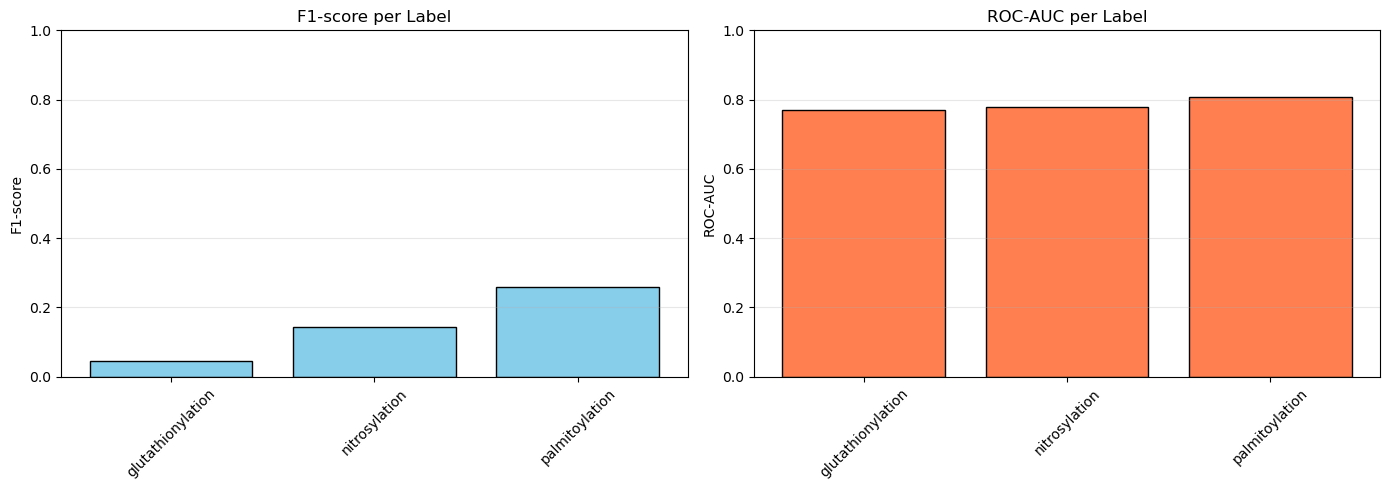

In [17]:
# Plot performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 scores
f1_scores = [results[label]['f1'] for label in label_cols]
axes[0].bar(range(len(label_cols)), f1_scores, color='skyblue', edgecolor='black')
axes[0].set_xticks(range(len(label_cols)))
axes[0].set_xticklabels([l.replace('S-', '') for l in label_cols], rotation=45)
axes[0].set_ylabel('F1-score')
axes[0].set_title('F1-score per Label')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC scores
auc_scores = [results[label]['auc'] for label in label_cols]
axes[1].bar(range(len(label_cols)), auc_scores, color='coral', edgecolor='black')
axes[1].set_xticks(range(len(label_cols)))
axes[1].set_xticklabels([l.replace('S-', '') for l in label_cols], rotation=45)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC per Label')
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/rf_{ENCODING_MTHD}_performance_plot.jpeg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 10. Save Models and Predictions

Save everything for:
1. Future predictions on test data
2. Ensembling with other models (XGBoost, CNN, GRU)
3. Comparison with teammates

In [ ]:
# Create output directory for this encoding
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# Save trained models
with open(f"{OUTPUT_DIR}/rf_models.pkl", 'wb') as f:
    pickle.dump(models, f)
print(f"✓ Saved to {OUTPUT_DIR}/rf_models.pkl")

# Save validation predictions (for ensemble)
val_pred_df = pd.DataFrame({
    'ID': val_df['ID'],
    'rf_glut_proba': val_predictions['S-glutathionylation'],
    'rf_nitro_proba': val_predictions['S-nitrosylation'],
    'rf_palm_proba': val_predictions['S-palmitoylation']
})
val_pred_df.to_csv(f"{OUTPUT_DIR}/rf_val_predictions.csv", index=False)
print(f"✓ Saved to {OUTPUT_DIR}/rf_val_predictions.csv")

# Save results summary
results_df = pd.DataFrame(results).T
results_df.to_csv(f"{OUTPUT_DIR}/rf_results.csv")
print(f"✓ Saved to {OUTPUT_DIR}/rf_results.csv")

print("\n" + "="*60)
print("✓ RANDOM FOREST TRAINING COMPLETE!")
print("="*60)
print(f"\nAll outputs saved to: {OUTPUT_DIR}/")
print("\nNext steps:")
print("1. Train XGBoost models (06_train_xgboost.ipynb)")
print("2. Compare RF vs XGBoost performance")
print("3. Create ensemble of both models")
print("4. Share rf_val_predictions.csv with teammates for final ensemble")
print("="*60)

## 11. Interpretation & Next Steps

### Why are F1 scores low?

**This is EXPECTED for highly imbalanced data!** Here's why:

1. **Severe class imbalance** (1:7 to 1:25 ratios)
   - Model is conservative, predicts negative most of the time
   - Misses many positive cases (low recall)
   - When it predicts positive, usually correct (high precision)

2. **Default threshold = 0.5**
   - Too high for imbalanced classes
   - Should tune to lower values (0.2-0.4)

3. **ROC-AUC is good (0.77-0.81)**
   - Model CAN discriminate between classes
   - Just needs better threshold tuning

### How to Improve:

1. **Threshold Tuning** (run `tune_hyperparameters.py`)
   - Find optimal threshold per label
   - Can boost F1 by 10-20%

2. **Hyperparameter Tuning**
   - Try different n_estimators (200, 400, 500)
   - Adjust min_samples_split, min_samples_leaf
   - Try max_depth limits

3. **Ensemble with XGBoost**
   - XGBoost often performs better than RF
   - Combining both usually gives 2-5% boost

4. **Add Deep Learning Models**
   - Get CNN/GRU predictions from teammates
   - Final ensemble: RF + XGBoost + CNN + GRU

5. **Feature Engineering v2**
   - Add more discriminative features
   - Di-peptides, physicochemical properties

### Expected Final Performance:
- **After threshold tuning**: F1 = 0.2-0.4, AUC = 0.78-0.85
- **After hyperparameter tuning**: F1 = 0.3-0.5, AUC = 0.80-0.88
- **After ensemble (RF+XGB)**: F1 = 0.4-0.6, AUC = 0.82-0.90
- **After full ensemble (+CNN+GRU)**: F1 = 0.5-0.7, AUC = 0.85-0.92